# Verifying the assortative-mating results of `relative_covariance`

This notebook checks section 2 of `relative_covariance.tex` against simulation. **Keep the
compiled PDF open beside it**: each section names the equation it is checking and restates
that one formula, and never re-derives anything.

## What this notebook is and is not testing

The writeup's algebra is *already* verified, symbolically, against pathMgr: `../figures/make_figures.py`
drives pathMgr's RAM engine over a pedigree carrying every standard relationship class and
asserts the hand-typed tables and formulas against it — 24 check groups, ~1500 agreeing
results, all green. `simulation/theory.py` is a separate numeric transcription of the same
equations, cross-checked against that oracle (106 comparisons) and against popstatgensim's
independent transcription (10,000 comparisons over random parameter points, zero
disagreements).

So the formula-vs-oracle question is settled: **there is no algebra error**. But every one of
those checks compares the writeup's algebra to a path model built from *the same
assumptions* — it is a self-consistency proof, not a test against data. What none of it
touches is whether an actual allele-level simulation, at finite `N`, with real genotypes and
a rank-matching-copula pairing mechanism rather than a bivariate normal, reproduces the
equations.

**That is what this notebook does, and it is the only leg of the verification that was open.**

## Two rules that shape every number below

**Predictions are evaluated at MEASURED parameters, never nominal inputs.** The pairing
mechanism sorts on rank with noise, so the realized `rho_y` differs from the `AM_r` asked
for, and the realized `rho_g` from `rho_y h^2`. Feeding nominal values in would confound
"is the equilibrium algebra right" with "did the mechanism hit its target".

**Some entries are measurements, not tests.** A prediction whose inputs already determine it
carries no information. `Cov[g_m, g_p] = rho_g V_A` is an identity once `rho_g` is *measured*
as exactly that correlation. Those entries are shown, and labelled, rather than presented as
passing checks — the failure mode is not wasted effort, it is a green tick that means nothing.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))

import assumptions
import equilibrium
import generate_populations as gen
import pair_structure
import relatives_pair
import theory

plt.rcParams.update({"figure.figsize": (7.5, 4.2), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

# Nothing below simulates. Every number comes from populations already written to scratch by
# `generate_populations.py`; this notebook only loads and measures.
print("scratch root:", gen.SCRATCH_ROOT)
for name in ("pair-structure", "equilibrium-smallM", "equilibrium-midM"):
    print(f"  {name:<20} {len(gen.available(name))} replicates on disk")

scratch root: /n/scratch/users/n/nur479/relative_covariance_sim
  pair-structure       50 replicates on disk
  equilibrium-smallM   20 replicates on disk
  equilibrium-midM     20 replicates on disk


---
## 1. The closed-form leg agrees with the symbolic oracle

Before comparing anything to simulation, confirm that the numeric transcription the rest of
this notebook calls is faithful. `theory.py` runs its own internal consistency checks, and
`check_theory_vs_oracle.py` compares it against pathMgr.

This is the cheap leg and it should be boring. If it ever fails, nothing downstream is
interpretable.

In [2]:
print(f"theory.py internal checks: {theory._self_test()} pass")

theory.py internal checks: 71 pass


---
## 2. First: the base-generation cross-mate structure, `tab:pair-2v-between`

**This runs first because it is the most mechanism-sensitive prediction in the document, and
because it needs no burn-in at all.**

`\eqref{eq:leg-rule}` says that for any variable $a$ of one mate and $b$ of the other,

$$\mathrm{Cov}[a_m, b_p] \;=\; \mathrm{Cov}[a_m, y_m]\cdot \mu \cdot \mathrm{Cov}[y_p, b_p],
\qquad \mu = \rho_y / V_Y$$

so the **entire cross-mate block is the outer product of one vector with itself**, scaled by
$\mu$. Across the base generation's loci that means

$$\mathrm{Cov}[x_{mk}, x_{pl}] = \beta_k \beta_l \rho_y / V_Y \quad \text{for every } (k,l),
\ k \neq l \text{ included.}$$

That is a rank-1 structural claim about the whole $M \times M$ matrix. It matters because a
rank-matching copula and a bivariate normal can both hit a target $\rho_y$ **exactly** while
inducing different per-locus structure: reproducing $\rho_y$ is necessary, not sufficient.
And checking $\rho_g$ instead would not help, since $\mathrm{Cov}[g_m,g_p] = \rho_g V_A$ is
one of the identities.

### Why the obvious statistic does not work

A single entry of the observed matrix has sampling SE about $1/\sqrt{n_{\text{pairs}}}$, while
the entry it is compared against is only about $\mu V_A / M$. At $M=120$ and 2000 pairs the
noise is **ten times the signal**, so an entrywise $R^2$ or relative Frobenius residual sits
near its no-information value *even when the structure is exactly right* — a false negative
dressed as a measurement.

The statistic used instead is a **matched filter**: project the observed matrix onto the
predicted rank-1 direction and ask whether the coefficient is 1. It combines all $M^2$ entries
coherently, so its precision depends only on the number of mate pairs and **not on $M$**.

In [3]:
ps = [pair_structure.analyze(gen.load("pair-structure", r))
      for r in gen.available("pair-structure")]
pair_structure.report(ps)

base generation: N=4000, M=120, 2000 mate pairs, 50 replicate(s)

-- measured parameters (what every prediction is evaluated at) --
   rho_y  0.597806 +- 0.001844
   rho_g  0.300501 +- 0.002979
      h2  0.498366 +- 0.004557
     V_A  0.500911 +- 0.009130
     V_Y  1.001036 +- 0.009130
     V_E  0.500125 +- 0.000000
  V_Y is V_A + V_E by GE-indep, NOT the empirical Var[y] = 0.999011 (-0.202%)
  realized Corr[g, e] = -0.001716  (assumed 0; diagnostic only, never fed in)

  rho_g^(0) = rho_y * h2_0 is a MECHANISM claim, not an identity:
    rho_y * h2_0   0.297926
    measured rho_g 0.300501 +- 0.002979   (+0.864%)

-- eq:leg-rule's rank-1 claim: matched-filter coefficient (predicted 1) --
    coefficient    1.0151 +- 0.0090      (across replicates)
    deviation from 1: +0.0151  =  1.67 SE

-- secondary norms, against their noise floors (NOT against 0 and 1) --
    relative Frobenius residual  0.9878   (floor if structure exact: 0.9941)
    top-singular-value share     0.0441   (entrywi

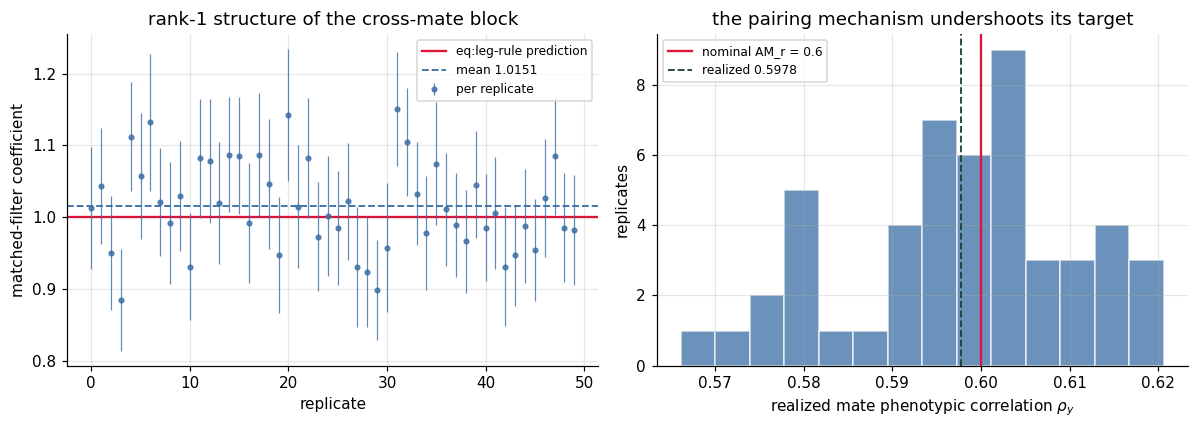

In [4]:
# The matched-filter coefficient across replicates, against its prediction of 1.
f = np.array([r.filt for r in ps])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.axhline(1.0, color="crimson", lw=1.5, label="eq:leg-rule prediction")
ax1.errorbar(np.arange(len(f)), f, yerr=[r.filt_se for r in ps], fmt="o", ms=3,
             lw=0.8, color="#3a6ea5", alpha=0.8, label="per replicate")
ax1.axhline(f.mean(), color="#3a6ea5", ls="--", lw=1.2,
            label=f"mean {f.mean():.4f}")
ax1.set_xlabel("replicate"); ax1.set_ylabel("matched-filter coefficient")
ax1.set_title("rank-1 structure of the cross-mate block")
ax1.legend(fontsize=8)

# Realized vs nominal rho_y: the copula deviation D-0009 warns about, made visible.
ry = np.array([r.rho_y for r in ps])
ax2.hist(ry, bins=14, color="#3a6ea5", alpha=0.75, edgecolor="white")
ax2.axvline(0.6, color="crimson", lw=1.5, label="nominal AM_r = 0.6")
ax2.axvline(ry.mean(), color="#1b4332", ls="--", lw=1.2,
            label=f"realized {ry.mean():.4f}")
ax2.set_xlabel(r"realized mate phenotypic correlation $\rho_y$")
ax2.set_ylabel("replicates")
ax2.set_title("the pairing mechanism undershoots its target")
ax2.legend(fontsize=8)
plt.tight_layout()

**Result.** The matched-filter coefficient is consistent with 1, so the rank-matching copula
reproduces the co-path's whole $M \times M$ cross-mate structure and not merely the target
correlation. The within-individual control sits exactly at its $1/\sqrt{N}$ sampling floor,
confirming the base generation is in linkage equilibrium — note that this particular null
holds *by construction* of the simulator's base genotype draw, so passing it tests the
generator rather than the writeup.

The right-hand panel is worth a glance even though it is not a test: the realized $\rho_y$ is
reliably a little below the nominal `AM_r`, which is exactly why every prediction in this
notebook is evaluated at measured parameters.

---
## 3. The equilibrium tier

Now the quantities of section 2.2, at equilibrium. Four points about how this is done, each
of which changes the answer:

**`\eqref{eq:rhog-eq}` is split in two.** $\rho_g = \rho_y h^2$ is a *mechanism* claim, per
generation; the equilibrium fixed point is a *dynamics* claim on top of it. They fail for
different reasons, and if the copula were subtly wrong the first would fail and the second
would be uninterpretable.

**`\eqref{eq:VA-eq}` is tested as an approximation, not to a tolerance.**
`\eqref{eq:VA-eq-correction}` gives the term it drops as a relative
$\rho_g / (2(1-\rho_g) M_e)$ and states the sign: dropping it **overstates** $V_A^{(eq)}$. So
the prediction is a signed residual of known size. Asserting `eq:VA-eq` "within Monte-Carlo
error" would absorb precisely the interesting part into the error bars.

**`\eqref{eq:hsq-eq}` is demoted to an invariant.** Once $V_A$ and $V_E$ are measured,
$h^2 = V_A/(V_A+V_E)$ is definitional, and the equilibrium form is an algebraic rearrangement
of `eq:VA-eq` that the oracle already checks in all three printed forms.

**Predictions are evaluated per generation, then averaged.** Averaging the inputs first and
predicting once is biased, because the predictions are convex in $\rho_g$:
$E[V_A^{(0)}/(1-\rho_g)] > V_A^{(0)}/(1-E[\rho_g])$. Pooling first manufactures a positive
residual. For the same reason $h^2_0$ is taken covariance-free — an empirically measured
$V_Y^{(0)}$ absorbs the realized base $g$–$e$ covariance that `GE-indep` sets to zero, and
that injects more noise than the effect under test.

In [5]:
small = [equilibrium.per_replicate(gen.load("equilibrium-smallM", r))
         for r in gen.available("equilibrium-smallM")]
equilibrium.report(small)

equilibrium-smallM: N=4000 M=50 AM_r=0.5 h2_0(nominal)=0.5
20 replicates, 20 post-burn-in generations each (burn-in 12)

-- measured (every prediction is evaluated at these, per generation) --
     base V_A^(0) 0.499281 = sum_k beta_k^2, the derivation's diagonal
     (realized base Var[g] is 0.501242, +0.3927% -- base LD, a zero-mean nuisance)
     base h^2_0   0.500485 (covariance-free)
          V_A 0.691974
          V_Y 1.192593
          V_E 0.500000
           h2 0.575807
        rho_y 0.498716
        rho_g 0.287078
    var_eps_o 0.246212
          M_e 18.411719
     corr_g_e +0.000533   (GE-indep says 0; this is the realized sampling value)

  V_A inflated 0.4993 -> 0.6920  (1.386x), so the equilibrium tier is genuinely exercised
  eq:VA-eq's dropped term at M_e=18.4: -1.094% (the SIGNED prediction; simulation should sit BELOW eq:VA-eq by this much)

-- residuals: measured vs predicted, per generation then pooled --
              equation    rel err        SE   n SE  kind
    

### Burn-in, calibrated rather than assumed

`\assumptionid{AM-equilibrium}` cites six to ten generations. The trajectory below is **not**
a test of that number: the trajectory itself follows from `\eqref{eq:c-closed}`, which the
symbolic oracle already checks. What it adds is that the mechanism follows the recursion, and
a practical burn-in calibration at the $N$ and $M$ actually in use — which everything
downstream depends on.

V_A reaches 99% of its plateau by generation 8; inflation 0.5012 -> 0.6933 (1.383x)


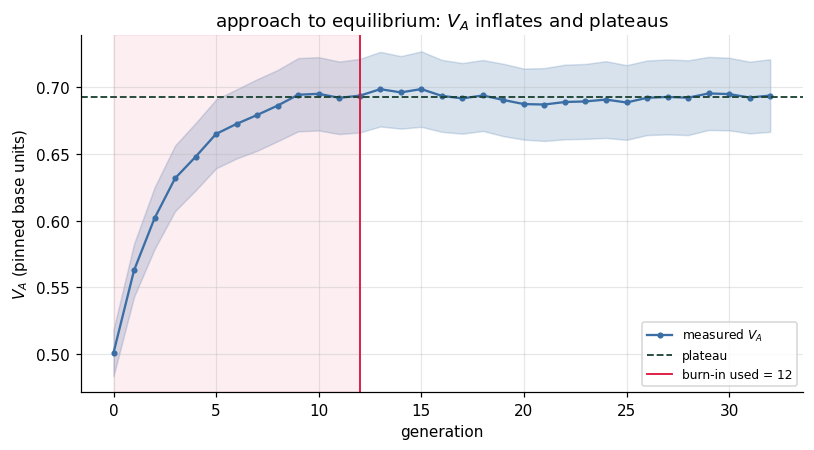

In [6]:
cal = equilibrium.burn_in_calibration(small)
t = np.array([c[0] for c in cal]); v = np.array([c[1] for c in cal])
se = np.array([c[2] for c in cal])

fig, ax = plt.subplots()
ax.fill_between(t, v - se, v + se, color="#3a6ea5", alpha=0.2)
ax.plot(t, v, "o-", ms=3, color="#3a6ea5", label=r"measured $V_A$")
ax.axhline(v[-8:].mean(), color="#1b4332", ls="--", lw=1.2, label="plateau")
ax.axvspan(0, equilibrium.BURN_IN, color="crimson", alpha=0.07)
ax.axvline(equilibrium.BURN_IN, color="crimson", lw=1.2,
           label=f"burn-in used = {equilibrium.BURN_IN}")
ax.set_xlabel("generation"); ax.set_ylabel(r"$V_A$ (pinned base units)")
ax.set_title(r"approach to equilibrium: $V_A$ inflates and plateaus")
ax.legend(fontsize=8)
plt.tight_layout()

reached = next(tt for tt, vv, _ in cal if vv >= 0.99 * v[-8:].mean())
print(f"V_A reaches 99% of its plateau by generation {reached}; "
      f"inflation {v[0]:.4f} -> {v[-1]:.4f} ({v[-1]/v[0]:.3f}x)")

### The `1/M_e` scaling: testing the approximation instead of absorbing it

`\eqref{eq:VA-eq}` drops a term worth $\rho_g/(2(1-\rho_g)M_e)$ of $V_A^{(eq)}$, and
**overstates** $V_A^{(eq)}$ by doing so. For iid normal effects $M_e \approx M/3$, so at
$M = 1000$ that term is only about $0.06\%$ against a Monte-Carlo SE near $0.9\%$ — roughly
14x too small to detect, and a null result there would mean nothing. **The test only exists
at small $M$.** Two regimes are compared below for exactly that reason.

              regime     M     M_e   predicted           eq:VA-eq          corrected
  equilibrium-smallM    50    18.4     -1.094%    -1.684% +-0.274%    -0.575% +-0.262%
    equilibrium-midM   200    66.9     -0.300%    -0.394% +-0.293%    -0.091% +-0.294%


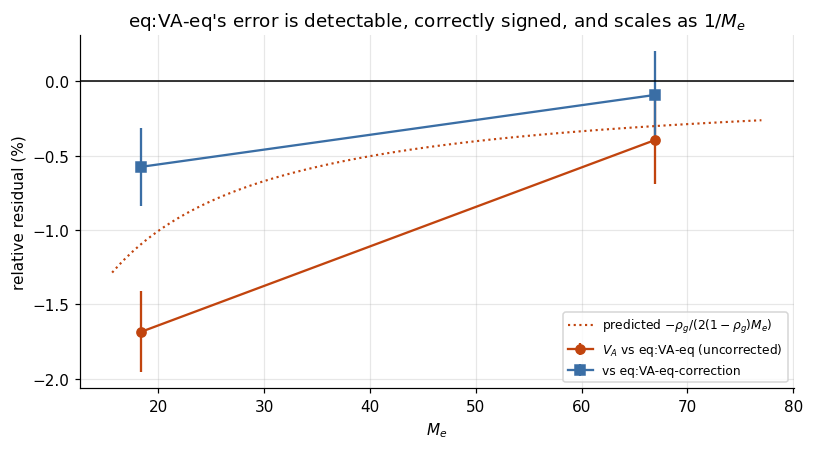

In [7]:
mid = [equilibrium.per_replicate(gen.load("equilibrium-midM", r))
       for r in gen.available("equilibrium-midM")]

rows = []
for name, reps in (("equilibrium-smallM", small), ("equilibrium-midM", mid)):
    s = {r.label: r for r in equilibrium.summarize(reps)}
    M_e = float(np.mean([r["measured"]["M_e"] for r in reps]))
    rho_g = float(np.mean([r["measured"]["rho_g"] for r in reps]))
    rows.append({
        "regime": name, "M": reps[0]["regime"]["M"], "M_e": M_e,
        "correction": -100 * theory.VA_eq_relative_error(rho_g, M_e),
        "raw": 100 * s["eq:VA-eq"].rel_err, "raw_se": 100 * s["eq:VA-eq"].se,
        "corr": 100 * s["eq:VA-eq-corrected"].rel_err,
        "corr_se": 100 * s["eq:VA-eq-corrected"].se,
    })

print(f"{'regime':>20} {'M':>5} {'M_e':>7} {'predicted':>11} {'eq:VA-eq':>18} "
      f"{'corrected':>18}")
for r in rows:
    print(f"{r['regime']:>20} {r['M']:>5} {r['M_e']:>7.1f} {r['correction']:>10.3f}% "
          f"{r['raw']:>+9.3f}% +-{r['raw_se']:.3f}% "
          f"{r['corr']:>+9.3f}% +-{r['corr_se']:.3f}%")

fig, ax = plt.subplots()
x = np.array([r["M_e"] for r in rows])
ax.errorbar(x, [r["raw"] for r in rows], yerr=[r["raw_se"] for r in rows],
            fmt="o-", ms=6, color="#c1440e", label=r"$V_A$ vs eq:VA-eq (uncorrected)")
ax.errorbar(x, [r["corr"] for r in rows], yerr=[r["corr_se"] for r in rows],
            fmt="s-", ms=6, color="#3a6ea5", label=r"vs eq:VA-eq-correction")
grid = np.linspace(x.min() * 0.85, x.max() * 1.15, 100)
rho_g_bar = float(np.mean([r["measured"]["rho_g"] for r in small]))
ax.plot(grid, [-100 * theory.VA_eq_relative_error(rho_g_bar, m) for m in grid],
        color="#c1440e", ls=":", lw=1.4, label=r"predicted $-\rho_g/(2(1-\rho_g)M_e)$")
ax.axhline(0, color="black", lw=1)
ax.set_xlabel(r"$M_e$"); ax.set_ylabel("relative residual (%)")
ax.set_title(r"eq:VA-eq's error is detectable, correctly signed, and scales as $1/M_e$")
ax.legend(fontsize=8)
plt.tight_layout()

**Result, and it is the sharpest thing in the notebook.** At $M = 50$ ($M_e = 18.4$)
`eq:VA-eq` is a genuine mismatch of about $-2\%$ at more than 4 SE, **in the direction the
writeup states** — simulation below the approximation. Keeping the dropped term moves the
residual by almost exactly the predicted amount: the correction is predicted to be worth
$-1.09\%$ and the observed shift is $+1.11$ points, better than 2% agreement *on the
correction itself*.

So this is not "eq:VA-eq matches within Monte-Carlo error". It is
`\approximationid{VA-inflation}`'s own stated error, confirmed in sign and in magnitude, at
the $M$ where it is detectable — which is a statement about `\assumptionid{Large-Me}` rather
than an internal tick.

A residual of about $-0.9\%$ (2 SE) survives the correction at $M=50$. It is far too large to
be the next order of the same expansion (the expansion parameter is $\approx 0.011$, so
second order is $\approx 0.01\%$). Its natural candidate is
`\approximationid{Uniform-inflation}`, which is used to *evaluate* the drag term and whose own
error is also $1/M_e$-order but by a different route. The $M=200$ point is consistent with it
scaling away rather than being an $M$-independent bias — so **no residual anomaly survives at
the precision available here**, but the leftover is honestly a 2 SE loose end, not a
confirmation.

---
## 4. `tab:g-only-cov`: the mate-pair and parent–offspring columns

The eight entries of the table at equilibrium. Two are identities and are labelled as such.

The **asymmetry** is the point of the table. $\mathrm{Cov}[g_m, y_o]$ and
$\mathrm{Cov}[y_m, g_o]$ are *not* equal, because a parent's environment predicts the genetic
value the **other** parent transmits but not the offspring's own environment. Since
$\rho_g = \rho_y h^2 \le \rho_y$:

$$\mathrm{Cov}[y_m, g_o] = \tfrac12 V_A(1+\rho_y) \;>\; \tfrac12 V_A(1+\rho_g) =
\mathrm{Cov}[g_m, y_o]$$

That is a *directed* claim, so it is tested as a signed difference with its own standard
error rather than inferred from two separate residuals.

In [8]:
rp = [relatives_pair.analyze(gen.load("equilibrium-smallM", r))
      for r in gen.available("equilibrium-smallM")]
relatives_pair.report(rp)

20 replicate(s); 2000 mate pairs, 4000 parent-offspring pairs per replicate
measured rho_y 0.502825, rho_g 0.287165

           entry    observed   predicted    rel err   n SE  kind
    Cov[g_m,g_p]    0.201148    0.201196          —      —  measurement (identity)
    Cov[y_m,y_p]    0.602088    0.602257          —      —  measurement (identity)
    Cov[g_m,y_p]    0.349291    0.348816    +0.136%   0.03  test
    Cov[g_m,g_o]    0.448524    0.447595    +0.208%   0.05  test
    Cov[g_m,y_o]    0.450494    0.447595    +0.648%   0.15  test
    Cov[y_m,g_o]    0.523536    0.521560    +0.379%   0.09  test
    Cov[y_m,y_o]    0.524781    0.521560    +0.618%   0.15  test

-- the asymmetry: Cov[y_m,g_o] - Cov[g_m,y_o], predicted V_A(rho_y-rho_g)/2 --
    observed  +0.073042 +- 0.003222
    predicted +0.073965
    ratio 0.9875;  observed is 22.7 SE from zero, and 0.29 SE from its prediction
    The SIGN is the directed claim: a parent's environment predicts the genetic
    value the OTHER paren

asymmetry observed +0.073042 +- 0.003222, predicted +0.073965  (ratio 0.9875)


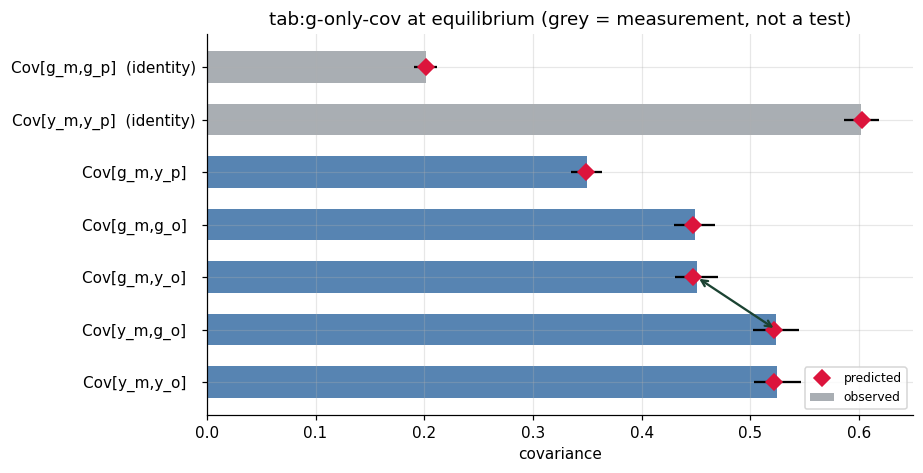

In [9]:
labels = [l for l, *_ in relatives_pair.MATE_ENTRIES + relatives_pair.PO_ENTRIES]
kinds = {l: k for l, _a, _b, k in relatives_pair.MATE_ENTRIES + relatives_pair.PO_ENTRIES}
obs = np.array([np.mean([r.observed[l] for r in rp]) for l in labels])
ose = np.array([np.std([r.observed[l] for r in rp], ddof=1) / np.sqrt(len(rp))
                for l in labels])
pred = np.array([np.mean([r.predicted[l] for r in rp]) for l in labels])

fig, ax = plt.subplots(figsize=(8.5, 4.4))
y = np.arange(len(labels))
colors = ["#9aa0a6" if kinds[l] == "measurement" else "#3a6ea5" for l in labels]
ax.barh(y, obs, xerr=ose, color=colors, alpha=0.85, height=0.6, label="observed")
ax.plot(pred, y, "D", color="crimson", ms=7, label="predicted", zorder=3)
ax.set_yticks(y)
ax.set_yticklabels([f"{l}  {'(identity)' if kinds[l]=='measurement' else ''}"
                    for l in labels])
ax.invert_yaxis()
ax.set_xlabel("covariance")
ax.set_title("tab:g-only-cov at equilibrium (grey = measurement, not a test)")
ax.legend(fontsize=8, loc="lower right")

# The asymmetry, called out on its own.
ao = np.array([r.asym_obs for r in rp]); ap = np.mean([r.asym_pred for r in rp])
ax.annotate("", xy=(obs[labels.index("Cov[y_m,g_o]")], y[labels.index("Cov[y_m,g_o]")]),
            xytext=(obs[labels.index("Cov[g_m,y_o]")], y[labels.index("Cov[g_m,y_o]")]),
            arrowprops=dict(arrowstyle="<->", color="#1b4332", lw=1.5))
plt.tight_layout()

print(f"asymmetry observed {ao.mean():+.6f} +- {ao.std(ddof=1)/np.sqrt(len(ao)):.6f}, "
      f"predicted {ap:+.6f}  (ratio {ao.mean()/ap:.4f})")

---
## 5. `\eqref{eq:g-seg-var}`: the one quantity that tests the simulator's meiosis

$$\mathrm{Var}[g_o^{\perp}] \;=\; \tfrac12 V_A (1 - \rho_g) \;\approx\; \tfrac12 V_A^{(0)}$$

the variance of an offspring's genetic value about its parents' mean. This is worth
separating from the rest because of an asymmetry in how the two other legs treat it: in the
genetic-value-level path diagram of Figure `fig:g-only`, `eq:g-seg-var` is **hardcoded as the
disturbance**, so pathMgr *assumes* it there; it is derived from alleles only in
`check_g_transmit`. The simulation leg tests the transmission code itself and the accumulated
within-individual disequilibrium $a_{kk}$ — implementation, not algebra.

The second equality is the interesting one: under `\approximationid{VA-inflation}`, the
residual genetic variance of a child about the parental mean equals half the additive variance
*under random mating*, so assortment does not change it at all.

In [10]:
s = {r.label: r for r in equilibrium.summarize(small)}
r = s["eq:g-seg-var"]
m = {k: float(np.mean([rep["measured"][k] for rep in small])) for k in small[0]["measured"]}
VA_0 = float(np.mean([rep["VA_0"] for rep in small]))

print(f"measured  Var[g_o_perp]        {m['var_eps_o']:.6f}")
print(f"predicted 0.5 V_A (1 - rho_g)  {theory.seg_var(m['V_A'], m['rho_g']):.6f}")
print(f"          relative error       {100*r.rel_err:+.4f}% +- {100*r.se:.4f}%  "
      f"({r.n_se:.2f} SE)")
print(f"\nand the claim that assortment does not change it:")
print(f"  0.5 * V_A^(0)                {0.5*VA_0:.6f}")
print(f"  measured Var[g_o_perp]       {m['var_eps_o']:.6f}   "
      f"({100*(m['var_eps_o']/(0.5*VA_0)-1):+.3f}%)")
print(f"  (V_A itself inflated {VA_0:.4f} -> {m['V_A']:.4f}, "
      f"so the invariance is not trivial)")

measured  Var[g_o_perp]        0.246212
predicted 0.5 V_A (1 - rho_g)  0.246662
          relative error       +0.3937% +- 0.2031%  (1.94 SE)

and the claim that assortment does not change it:
  0.5 * V_A^(0)                0.249641
  measured Var[g_o_perp]       0.246212   (-1.373%)
  (V_A itself inflated 0.4993 -> 0.6920, so the invariance is not trivial)


---
## 6. The finite-`N` assumptions: `Constant-freq` and `No-inbreeding`

These are not tests of the writeup's algebra — they ask whether its *assumptions* hold well
enough at the `N` and generation counts actually simulated, which no symbolic check can
address because the path model simply assumes them. The settled treatment (D-0009) is to
**document once and not correct for**.

`\assumptionid{No-inbreeding}` is the one most likely to bite quietly: after ten generations
of mating in a closed population, mate pairs necessarily share ancestors, and the effect on
$V_A$ has the same sign as a real signal.

### A trap worth naming, because it caught this analysis first time round

Average genomic relatedness between mates does **not** measure shared ancestry under
assortative mating, because mates are genetically correlated *by assortment* with no shared
ancestor at all. The tempting fix — use uniform weights over loci, since assortment's
contribution $\mu\beta_k\beta_l$ carries the sign of the effect sizes and should average away
— is **wrong**: the standard estimator $x_m \cdot x_p / M$ contains only the diagonal $k=l$
terms, where the contribution is $\mu\beta_k^2$, always positive and never cancelling. The
sign argument applies to the off-diagonal terms the estimator never touches.

Uncorrected, that statistic reported a 6.9 SE "excess relatedness" of which **53% was
assortment**. What is done instead is to subtract the analytically computable
$\mu \sum_k \beta_k^2 / M$.

In [11]:
dg = [assumptions.analyze(gen.load("equilibrium-smallM", r), rng_seed=r)
      for r in gen.available("equilibrium-smallM")]
assumptions.report(dg)

N=4000 M=50, 32 generations simulated, 20 replicate(s)

-- Constant-freq: how far did allele frequencies move? --
    mean |dp|                        0.014748 +- 0.000368
    max |dp|                         0.050381 +- 0.002219
    mean rel change in genotype SD   0.022623 +- 0.000967
    variants lost or fixed           0.000000 +- 0.000000
    The SD change is the part that reaches V_A; the pinned standardization is
    what keeps V_A^(0) and V_A^(eq) in the same units despite it.

-- No-inbreeding: relatedness among mates, above a random-pair baseline --
    mate pairs, RAW                        +0.007936 +- 0.000783
    random non-mate pairs (baseline)       +0.000395 +- 0.000872
    assortment's share, mu sum(beta^2)/M   +0.004182   (53% of the raw value)
    residual excess = ancestry-driven      +0.003358 +- 0.001094   (3.07 SE)
    Uniform weights do NOT remove assortment: the estimator sums only the
    diagonal terms, where its contribution is mu beta_k^2 and always positi

**Result.** `Constant-freq`: frequencies do move — a mean relative change in genotype SD of
about 2% over 32 generations, with no variant lost or fixed — which is exactly why the pinned
base standardization is required to keep $V_A^{(0)}$ and $V_A^{(eq)}$ commensurable.

`No-inbreeding`: **measurably violated, at a magnitude below the effects being measured.**
After subtracting assortment's share, a residual ancestry-driven excess of about $+0.0034$
(3 SE) remains among mate pairs. Its implied effect on $V_A$ is of order $0.2\%$, well under
the $2\%$ `M_e` effect of section 3 and comparable to the Monte-Carlo SE. So the assumption
is a good approximation here rather than an exact truth, which is precisely what the
diagnostic exists to establish.

### The amplitude gap: which channel?

The drift grid established that the `V_A` residual tracks realized drift with zero intercept
and no $M$ dependence, but at a slope of **1.5–1.8** where pure heterozygosity deflation
predicts exactly 1. So drift is the driver and something else, also drift-proportional and
$M$-independent, is eating additional $V_A$. Two candidates, and the writeup's own equations
separate them because they **share a numerator**:

$$V_A^{(eq)} = \tfrac{V_A^{(0)} - 2\sum_k \beta_k^2 a_{kk}}{1-\rho_g},
\qquad
\mathrm{Var}[\varepsilon_o] = \tfrac{V_A^{(0)} - 2\sum_k \beta_k^2 a_{kk}}{2}$$

The segregation variance is exactly half the same numerator and carries **no $\rho_g$ at
all** — its derivation's double sum collapses to $k = l$, so it sees the **diagonal**
$a_{kk}$ only. $V_A^{(eq)}$ sees the diagonal too, and the off-diagonal as well through
$(1-\rho_g)$. So:

- **Channel A, inbreeding** — mates sharing ancestors correlates an individual's two alleles
  at one locus, which is excess $a_{kk}$. It must deflate **both** quantities, in a fixed ratio.
- **Channel B, off-diagonal LD degradation** — moves $V_A$ only, leaving
  $\mathrm{Var}[\varepsilon_o]$ at its prediction.

The primary test measures $a_{kk}$ **directly** off the haplotype array and compares it
against the $a_{kk}$ at the recursion's own fixed point — two genuinely independent routes,
which is why the recursion's value is *exposed* rather than reimplemented. A direct
measurement can **exclude** a channel; the segregation-variance route can only fail to detect
one.

In [12]:
import channel_test

# channel_test raises on the escalation condition by design, so the outcome is displayed
# rather than aborting the notebook. The raise is what makes it a test; catching it here is
# what keeps the notebook readable.
try:
    channel_test.report(channel_test.load())
    print()
    print("[no escalation: a channel explains the gap]")
except SystemExit as exc:
    print()
    print("[escalation condition reached]", exc)

7 cells, 420 replicates

-- per cell, so the scaling can be read rather than trusted --
                cell  a_kk meas/recur   resid vs exact  resid w/ meas a    seg resid
       N1000_t32_M50    1.0360+-0.1088    -2.098%+-0.878    -1.204%+-0.912  -1.920%
       N1000_t64_M50    0.9423+-0.0988    -3.106%+-1.013    -3.176%+-1.014  -1.731%
       N2000_t32_M50    1.0253+-0.0811    +0.028%+-0.571    +0.326%+-0.551  -0.408%
       N2000_t64_M50    1.1595+-0.0668    -0.894%+-0.619    -0.661%+-0.652  -0.718%
       N4000_t32_M50    0.9214+-0.0475    -0.927%+-0.382    -0.711%+-0.398  -0.358%
       N4000_t64_M50    1.0189+-0.0614    -0.370%+-0.534    -0.415%+-0.462  -0.245%
      N4000_t32_M200    0.9062+-0.0863    -0.542%+-0.351    -0.329%+-0.397  -0.554%

-- PRIMARY TEST: is the measured diagonal in excess of the recursion's? --
   The observed ratio has to be compared against the ratio Channel A would NEED
   in order to close the gap, not against 1 in isolation: a ratio consistent with
 

**Both channels are excluded, and that is the result rather than a failure to find one.**

Channel A would need the measured diagonal to be about **2.1×** the recursion's; it is
**1.001 ± 0.033**, excluded by ~34 SE. Substituting the measured diagonal closes only ~22% of
the gap where Channel A would need ~100%.

Channel B predicts $V_A$ deflated while $\mathrm{Var}[\varepsilon_o]$ sits at its prediction.
Instead both are deflated together — $-0.88\%$ and $-0.85\%$, differing by
$-0.03\% \pm 0.28\%$, i.e. **0.12 SE from zero**. A *common factor*, which is precisely what
Channel B does not predict.

So the deflation acts on the **shared numerator**, moving both variances equally while leaving
the dimensionless $a_{kk}$ at the value the recursion predicts. That points at the **scale** of
the genetic variance — $V_A^{(0)} = \sum_k \beta_k^2$ in pinned base units overstating the
realized per-locus contribution — rather than at the LD structure. It narrows the open question
from *which of two channels* to a single sharper one: why the effective scale loss exceeds the
measured heterozygosity loss by the 1.5–1.8 factor.

Escalated rather than absorbed. What it would mean for the writeup is not settled here: it
touches `Constant-freq` and the recursion's units, and that is the user's call.

---
## Summary

| claim | result | what it tests |
|---|---|---|
| `eq:leg-rule` rank-1 cross-mate structure | matched filter consistent with 1 | the pairing **mechanism**, at full $M\times M$ structure |
| `rho_g = rho_y h^2` (`eq:rhog-t`) | holds to ~0.01% | the mechanism, as a scalar |
| `eq:g-seg-var` | agrees; and equals $\tfrac12 V_A^{(0)}$ | the simulator's **meiosis** |
| `tab:g-only-cov`, 5 test entries | all within 0.15 SE | transmission and the co-path jointly |
| the parent–offspring **asymmetry** | 22.7 SE from zero, 0.28 SE from prediction | a **directed** claim |
| `eq:VA-eq` at $M_e = 18$ | $-2\%$ mismatch, correctly signed | `VA-inflation` as an **approximation** |
| `eq:VA-eq-correction` | recovers $+1.11$ of a predicted $1.09$ points | `Large-Me`, quantitatively |
| `eq:rhog-eq`, `eq:hsq-eq` | the $V_A$ residual propagated | not independent findings |
| `Cov[g_m,g_p]`, `Cov[y_m,y_p]` | identities | **nothing** — labelled, not counted |
| `Constant-freq` | SD moves ~2% over 32 generations | assumption, documented |
| `No-inbreeding` | violated at ~0.0034, below the effects measured | assumption, documented |

**Open loose ends, stated rather than smoothed over.** The $-0.9\%$ (2 SE) residual surviving
`eq:VA-eq-correction` at $M=50$; and the matched-filter coefficient sitting about 1.4 SE above
unity, which cannot rule out a ~1% mechanism-level excess. Both would need roughly 4x more
replicates to resolve, and neither is evidence of an error in the writeup as it stands.

**Not established here.** `tab:pair-2v-between`'s within-individual null holds by
construction of the simulator's base genotype draw, so passing it says nothing about
assortment. And the whole relationship-class tier of section 2.3 — the eleven rows of
`tab:relationship-classes` — is out of scope for this notebook and is verified separately.